# Stage 3 — The Fourier Neural Operator (FNO)

## From the integral kernel operator to spectral convolution

Recall the neural operator layer update (paper Eq. 10, dropping the local linear term and bias for clarity):
$$v_{t+1}(x) = \sigma\Big(\int_D \kappa(x,y)\, v_t(y)\, dy\Big)$$

Directly learning $\kappa(x,y)$ and computing this integral costs $O(J^2)$ for $J$ grid points (Section 4, "Kernel Matrix"). FNO's key idea (Section 4.4) is to restrict to **translation-invariant** kernels, $\kappa(x,y)=\kappa(x-y)$, turning the integral into a convolution:
$$(\mathcal{K}v)(x) = (\kappa * v)(x)$$
By the convolution theorem this is diagonal in the Fourier basis:
$$\mathcal{F}[\mathcal{K}v](k) = \mathcal{F}[\kappa](k)\cdot \mathcal{F}[v](k)$$
So instead of learning $\kappa$ in physical space, FNO **directly parameterizes a finite set of Fourier coefficients** $R_k := \mathcal{F}[\kappa](k)$ for the lowest $k_{max}$ modes and zeroes out the rest. A layer becomes:
$$v_{t+1}(x) = \sigma\Big(W v_t(x) + \mathcal{F}^{-1}\big(R \cdot \mathcal{F}(v_t)\big)(x) + b(x)\Big)$$
implemented as **FFT → multiply by learned complex weights on the low modes → inverse FFT**, at cost $O(J\log J)$. Crucially, the number of learned parameters ($R_k$ for $|k|\le k_{max}$) does **not depend on the grid resolution $J$** — this is exactly what gives FNO its discretization-invariance (Definition 4 in the paper): the same trained weights can be applied to an input function sampled on any grid.

This is implemented in `neural_operators/layers/spectral_conv.py` (`SpectralConv2d`) and assembled into the full architecture in `neural_operators/models/fno.py` (`FNO2d`), following the overall neural operator structure of Eq. (6): lift $P$ → $T$ Fourier layers → project $Q$.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import torch
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

from neural_operators.models.fno import FNO2d
from neural_operators.utils import train_model, evaluate, count_params, measure_inference_time, RelativeL2Loss
from neural_operators.data.grf import GaussianRF2d
from neural_operators.data.navier_stokes_2d import solve_navier_stokes_2d, default_forcing

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [2]:
cache = torch.load("../data_cache/navier_stokes_64.pt")
a_data, u_data = cache["a"], cache["u"]
n_train, n_test = cache["n_train"], cache["n_test"]
n = cache["n"]
print("loaded", a_data.shape, "train/test split:", n_train, n_test)

# normalize by training-set statistics (standard practice, helps optimization)
a_mean, a_std = a_data[:n_train].mean(), a_data[:n_train].std()
u_mean, u_std = u_data[:n_train].mean(), u_data[:n_train].std()
a_norm = (a_data - a_mean) / a_std
u_norm = (u_data - u_mean) / u_std

train_ds = TensorDataset(a_norm[:n_train], u_norm[:n_train])
test_ds = TensorDataset(a_norm[n_train:], u_norm[n_train:])
train_loader = DataLoader(train_ds, batch_size=20, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=20, shuffle=False)

loaded torch.Size([240, 64, 64]) train/test split: 200 40


In [3]:
model = FNO2d(in_channels=3, out_channels=1, width=32, modes1=12, modes2=12, n_layers=4)
print("trainable parameters:", count_params(model))

history = train_model(model, train_loader, test_loader, epochs=150, lr=1e-3, device=device, verbose_every=10)

trainable parameters: 1188353


epoch    0 | train rel-L2 0.9909 | test rel-L2 0.9537 | 1.1s


epoch   10 | train rel-L2 0.0351 | test rel-L2 0.0356 | 3.3s


epoch   20 | train rel-L2 0.0323 | test rel-L2 0.0350 | 5.4s


epoch   30 | train rel-L2 0.0323 | test rel-L2 0.0404 | 7.6s


...

epoch  110 | train rel-L2 0.0196 | test rel-L2 0.0244 | 24.8s


epoch  120 | train rel-L2 0.0193 | test rel-L2 0.0236 | 26.9s


epoch  130 | train rel-L2 0.0187 | test rel-L2 0.0233 | 29.1s


epoch  140 | train rel-L2 0.0185 | test rel-L2 0.0233 | 31.2s


epoch  149 | train rel-L2 0.0184 | test rel-L2 0.0233 | 33.2s


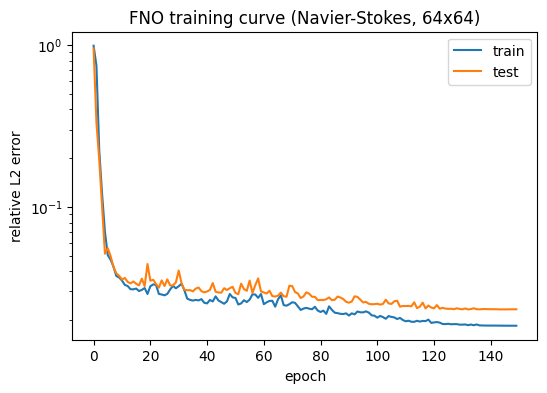

final test relative L2 error: 0.0233


In [4]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["test_loss"], label="test")
plt.xlabel("epoch")
plt.ylabel("relative L2 error")
plt.yscale("log")
plt.legend()
plt.title("FNO training curve (Navier-Stokes, 64x64)")
plt.show()

print(f"final test relative L2 error: {history['test_loss'][-1]:.4f}")

## Qualitative check: predicted vs. true vorticity

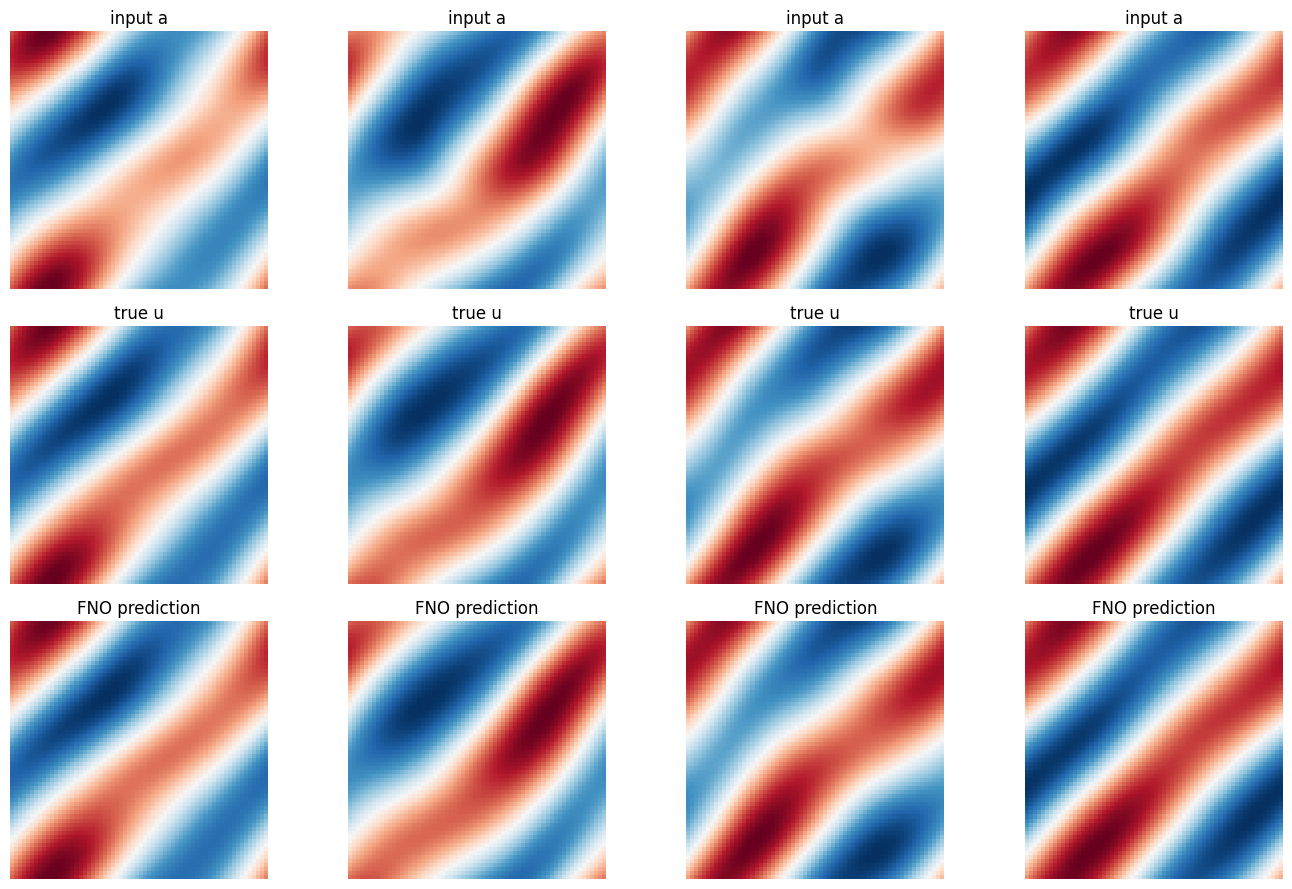

In [5]:
model.eval()
with torch.no_grad():
    x_sample, y_sample = next(iter(test_loader))
    pred = model(x_sample.to(device)).cpu()

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for i in range(4):
    axes[0, i].imshow(x_sample[i] * a_std + a_mean, cmap="RdBu_r")
    axes[0, i].set_title("input a")
    axes[0, i].axis("off")
    axes[1, i].imshow(y_sample[i] * u_std + u_mean, cmap="RdBu_r")
    axes[1, i].set_title("true u")
    axes[1, i].axis("off")
    axes[2, i].imshow(pred[i] * u_std + u_mean, cmap="RdBu_r")
    axes[2, i].set_title("FNO prediction")
    axes[2, i].axis("off")
plt.tight_layout()
plt.show()

## Discretization invariance: evaluating at a resolution never seen during training

This is the paper's central claim about neural operators (Definition 4 / Section 8): a model with a **fixed number of parameters** should converge to the same continuum operator regardless of the grid it is evaluated on. We test this directly: generate a **fresh** Navier-Stokes test set at $128\times128$ (double the training resolution, independent random initial conditions) with the exact same PDE solver, and evaluate the *already-trained* FNO on it — no retraining, no architecture changes.

resolution   32x32   -> relative L2 error: 0.0191


resolution   64x64   -> relative L2 error: 0.0141


resolution   96x96   -> relative L2 error: 0.0224


resolution  128x128  -> relative L2 error: 0.0180


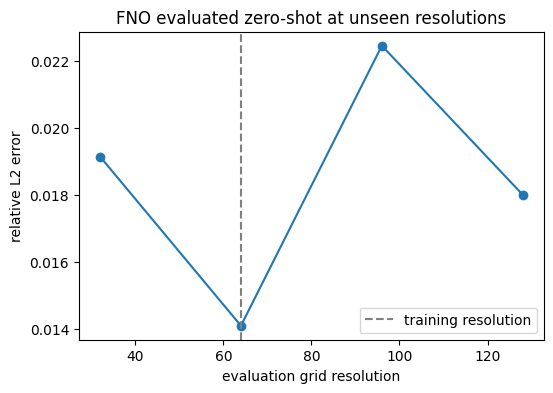

In [6]:
def make_hr_test_set(n_hr, n_samples=40, seed=123):
    g = torch.Generator(device=device).manual_seed(seed) if device == "cuda" else torch.manual_seed(seed)
    grf_hr = GaussianRF2d(n_hr, alpha=2.5, tau=7.0, device=device)
    f_hr = default_forcing(n_hr, device=device)
    w0 = grf_hr.sample(n_samples)
    burnin, _ = solve_navier_stokes_2d(w0, f_hr, visc=1e-3, T=4.5, delta_t=1e-3, record_steps=1)
    a = burnin[..., -1]
    traj, _ = solve_navier_stokes_2d(a, f_hr, visc=1e-3, T=2.0, delta_t=1e-3, record_steps=1)
    u = traj[..., -1]
    return a.cpu(), u.cpu()

resolutions = [32, 64, 96, 128]
errors = []
loss_fn = RelativeL2Loss()

for res in resolutions:
    a_res, u_res = make_hr_test_set(res, n_samples=30)
    a_res_n = (a_res - a_mean) / a_std
    u_res_n = (u_res - u_mean) / u_std
    with torch.no_grad():
        pred = model(a_res_n.to(device))
    err = loss_fn(pred.cpu(), u_res_n).item()
    errors.append(err)
    print(f"resolution {res:>4d}x{res:<4d} -> relative L2 error: {err:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(resolutions, errors, marker="o")
plt.axvline(64, color="gray", linestyle="--", label="training resolution")
plt.xlabel("evaluation grid resolution")
plt.ylabel("relative L2 error")
plt.title("FNO evaluated zero-shot at unseen resolutions")
plt.legend()
plt.show()

If the model is truly discretization-invariant, error should stay roughly **flat** across resolutions (small fluctuations are expected since each resolution's test set uses different random samples and the model was optimized specifically for 64x64) rather than degrading sharply — unlike a plain CNN/MLP tied to a fixed grid, which cannot even be evaluated at a different resolution without architectural changes (see Table 1 in the paper).

## Timing vs. the numerical solver

The paper's headline efficiency result: FNO inference is orders of magnitude faster than the pseudo-spectral solver used to generate the training data.

In [7]:
x_batch = a_norm[:20]
fno_time = measure_inference_time(model, x_batch, device=device)

w0 = a_data[:20].to(device)
f = default_forcing(n, device=device)
import time
if device == "cuda":
    torch.cuda.synchronize()
t0 = time.time()
solve_navier_stokes_2d(w0, f, visc=1e-3, T=2.0, delta_t=1e-3, record_steps=1)
if device == "cuda":
    torch.cuda.synchronize()
solver_time = (time.time() - t0) / 20

print(f"FNO inference time per sample:    {fno_time*1000:.3f} ms")
print(f"Pseudo-spectral solver per sample: {solver_time*1000:.3f} ms")
print(f"speedup: {solver_time/fno_time:.1f}x")

FNO inference time per sample:    5.588 ms
Pseudo-spectral solver per sample: 95.602 ms
speedup: 17.1x


In [8]:
import json
os.makedirs("../results", exist_ok=True)
torch.save(model.state_dict(), "../results/fno_navier_stokes.pt")
with open("../results/fno_summary.json", "w") as fp:
    json.dump({
        "params": count_params(model),
        "final_test_rel_l2": history["test_loss"][-1],
        "inference_time_s": fno_time,
        "solver_time_s": solver_time,
        "discretization_invariance": dict(zip(resolutions, errors)),
    }, fp, indent=2)
print("saved model + summary to ../results/")

saved model + summary to ../results/


## Next step

`03_gno.ipynb` implements the **Graph Neural Operator**, which parameterizes the same integral kernel operator $\int \kappa(x,y)v(y)\,dy$ directly (without the translation-invariance restriction FNO relies on), using a Nyström approximation, radius truncation, and message passing on a graph built from the (possibly irregular) grid points.